# 04 — Policy Comparison

This notebook compares lifecycle policies by running individual simulations
and a policy sweep to evaluate TCO impact.

In [1]:
import sys
sys.path.insert(0, '..')

import copy

from dc_tco.config import load_config
from dc_tco.simulation import run_simulation
from dc_tco.plotting import plot_tco_breakdown, plot_server_timeline

In [2]:
cfg = load_config('../configs/default.yaml')

## Individual Policy Runs

In [4]:
policies = ['baseline', 'replace_all', 'disaggregated']
# Add extend_lifetime variants: 1yr, 2yr, 3yr extensions
extend_years_options = [1, 2, 3]

results = {}

for policy_name in policies:
    pcfg = copy.deepcopy(cfg)
    pcfg.policy.name = policy_name
    results[policy_name] = run_simulation(pcfg)

for ext_yr in extend_years_options:
    label = f'extend_lifetime_{ext_yr}yr'
    pcfg = copy.deepcopy(cfg)
    pcfg.policy.name = 'extend_lifetime'
    pcfg.policy.extend_lifetime_years = ext_yr
    results[label] = run_simulation(pcfg)

print(f'{"Policy":<25s} {"TCO ($B)":>12s} {"CapEx ($B)":>12s} {"OpEx ($B)":>12s}')
print('-' * 65)
baseline_tco = results['baseline'].total_tco
for name, r in results.items():
    pct = (r.total_tco / baseline_tco - 1) * 100
    print(f'  {name:<23s} ${r.total_tco/1e9:>10.3f}  '
          f'${r.tco_breakdown.total_capex/1e9:>10.3f}  '
          f'${r.tco_breakdown.total_opex/1e9:>10.3f}  ({pct:+.1f}%)')

Policy                        TCO ($B)   CapEx ($B)    OpEx ($B)
-----------------------------------------------------------------
  baseline                $     3.138  $     2.688  $     0.450  (+0.0%)
  replace_all             $     9.678  $     9.351  $     0.327  (+208.5%)
  disaggregated           $    13.538  $    11.755  $     1.784  (+331.5%)
  extend_lifetime_1yr     $     2.980  $     2.510  $     0.470  (-5.0%)
  extend_lifetime_2yr     $     2.963  $     2.486  $     0.477  (-5.6%)
  extend_lifetime_3yr     $     2.957  $     2.477  $     0.479  (-5.8%)


## Side-by-Side TCO Breakdown

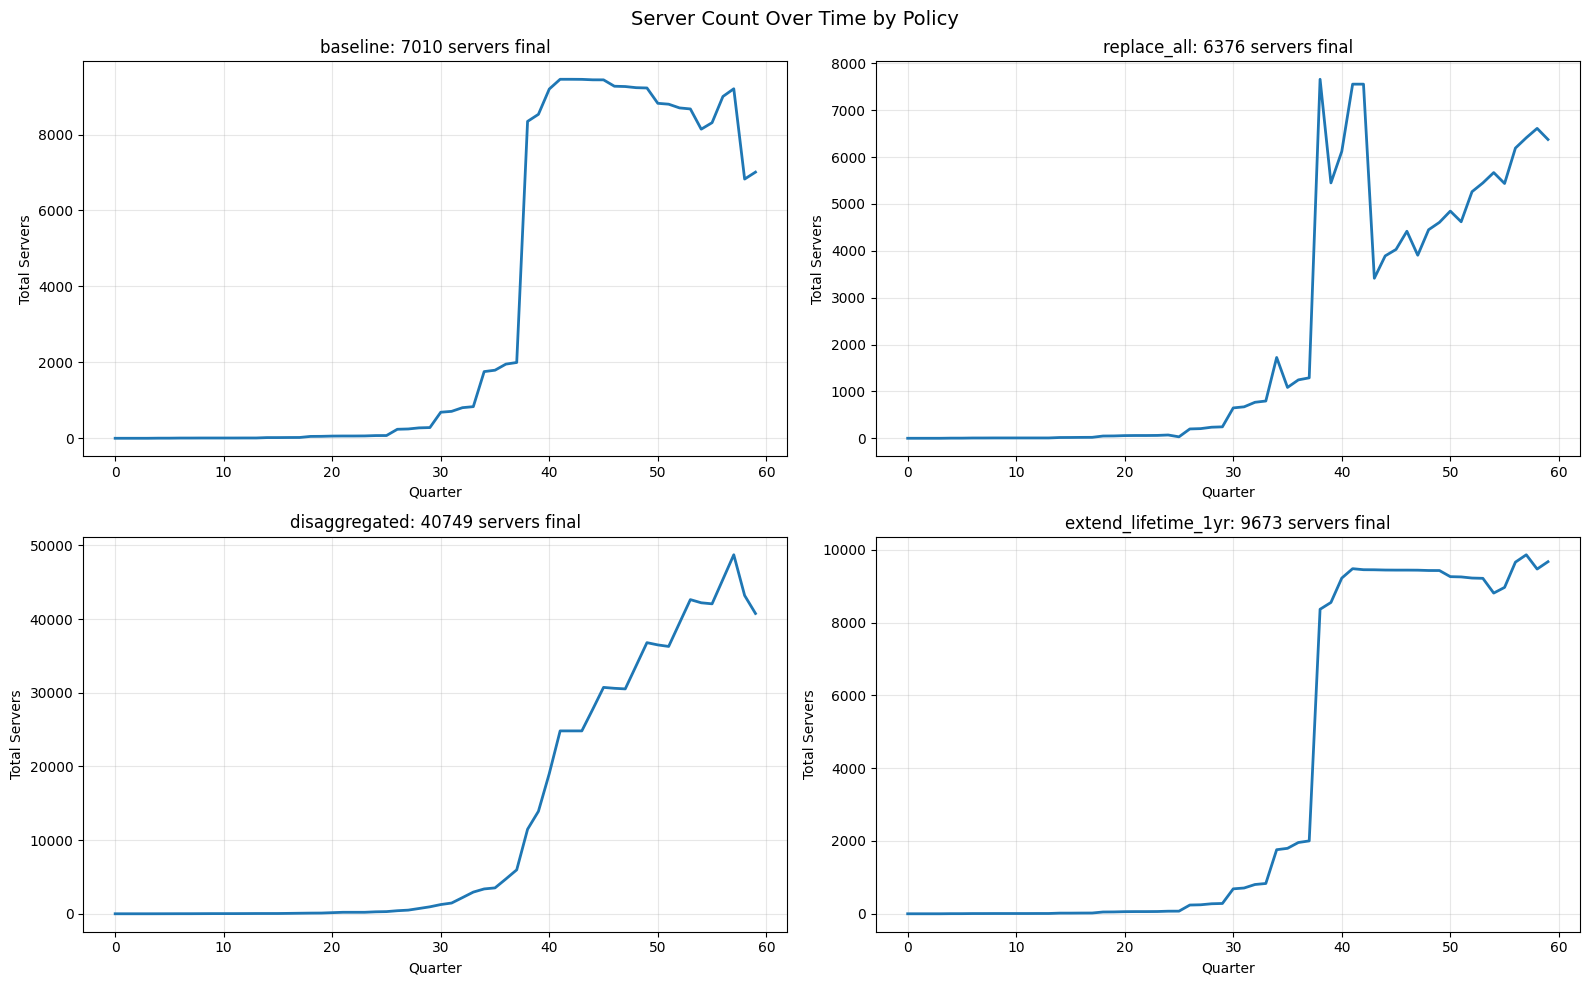

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    plot_server_timeline.__wrapped__(r) if hasattr(plot_server_timeline, '__wrapped__') else None
    quarters = [s.quarter for s in r.quarterly_states]
    servers = [s.total_servers for s in r.quarterly_states]
    ax.plot(quarters, servers, linewidth=2)
    ax.set_title(f'{name}: {r.quarterly_states[-1].total_servers} servers final')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Total Servers')
    ax.grid(True, alpha=0.3)

fig.suptitle('Server Count Over Time by Policy', fontsize=14)
plt.tight_layout()

## Policy Sweep (with generation skipping)

In [6]:
from dc_tco.scenarios import run_policy_sweep
from dc_tco.plotting import plot_policy_comparison

# Run a smaller sweep (no disaggregated, no skip combos for speed)
sweep_results = run_policy_sweep(
    cfg,
    include_disaggregated=False,
    include_skip=False,
    max_extend_years=3,
)

print(f'Sweep produced {len(sweep_results)} results')
for r in sorted(sweep_results, key=lambda x: x.total_tco):
    print(f'  {r.policy_name:<30s} ${r.total_tco/1e9:>10.3f} B')

Sweep produced 5 results
  extend_3y                      $     2.957 B
  extend_2y                      $     2.963 B
  extend_1y                      $     2.980 B
  baseline                       $     3.138 B
  replace_all                    $     9.678 B


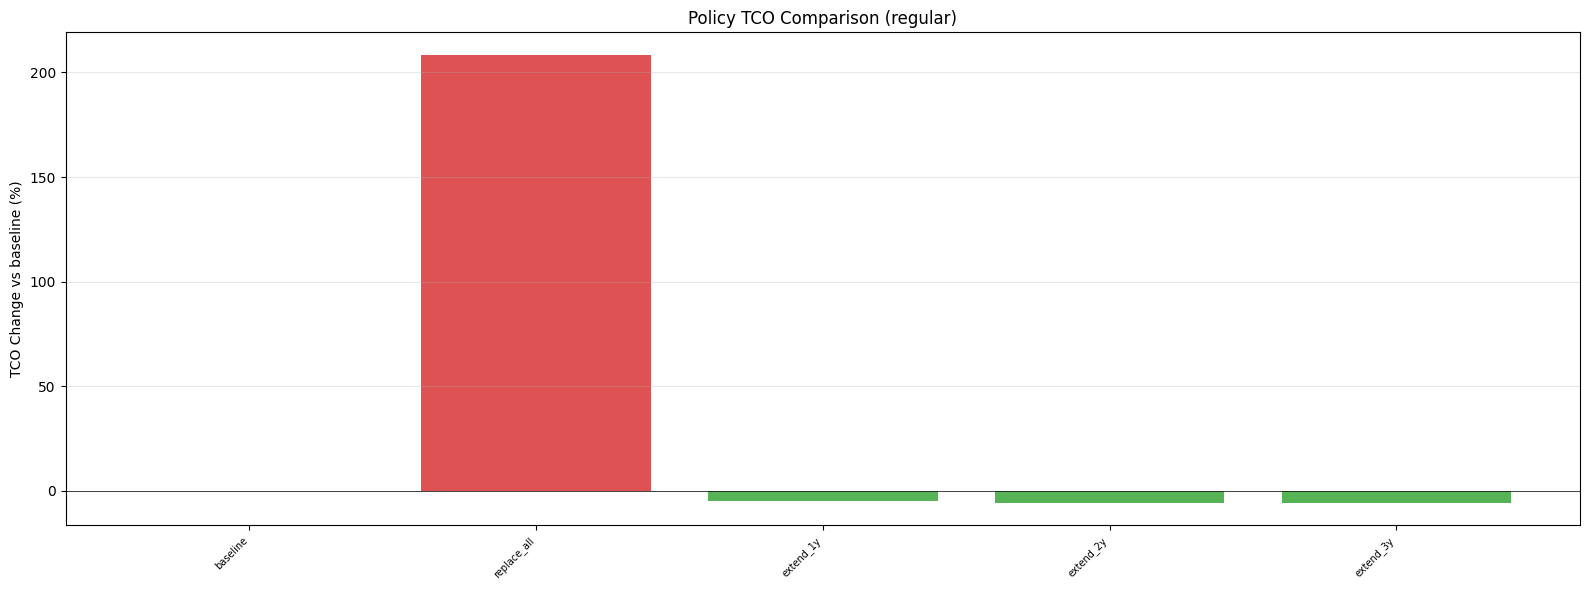

In [7]:
fig = plot_policy_comparison(sweep_results, normalize_to='baseline')